# Lab 4: Phân tích dữ liệu thiết bị người dùng - Data Wrangling
## 22684591 - Trần Thị Thanh Thảo

### Mục tiêu:
- Phân tích dữ liệu sử dụng thiết bị của người dùng
- Làm sạch và tiền xử lý dữ liệu (Data Wrangling)
- Kết hợp dữ liệu từ nhiều nguồn
- Phân tích xu hướng sử dụng thiết bị
- Trực quan hóa dữ liệu và đưa ra insights


In [17]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Thiết lập hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Đã import thành công các thư viện cần thiết!")


Đã import thành công các thư viện cần thiết!


## 1. Tải và khám phá dữ liệu


In [18]:
# Tải dữ liệu người dùng và thiết bị
print("="*60)
print("TẢI DỮ LIỆU")
print("="*60)

# Tải dữ liệu sử dụng thiết bị của người dùng
df_users = pd.read_csv('nguoidung_thietbi.csv')
print("1. Dữ liệu người dùng và thiết bị:")
print(f"   - Kích thước: {df_users.shape}")
print(f"   - Các cột: {list(df_users.columns)}")

# Tải dữ liệu thông tin thiết bị
df_devices = pd.read_csv('thietbi.csv')
print(f"\n2. Dữ liệu thông tin thiết bị:")
print(f"   - Kích thước: {df_devices.shape}")
print(f"   - Các cột: {list(df_devices.columns)}")

print("\n" + "="*60)
print("THÔNG TIN CƠ BẢN VỀ DỮ LIỆU")
print("="*60)


TẢI DỮ LIỆU
1. Dữ liệu người dùng và thiết bị:
   - Kích thước: (272, 6)
   - Các cột: ['use_id', 'user_id', 'platform', 'platform_version', 'device', 'use_type_id']

2. Dữ liệu thông tin thiết bị:
   - Kích thước: (14546, 4)
   - Các cột: ['Retail Branding', 'Marketing Name', 'Device', 'Model']

THÔNG TIN CƠ BẢN VỀ DỮ LIỆU


In [19]:
# Hiển thị dữ liệu mẫu
print("Dữ liệu người dùng và thiết bị (5 dòng đầu):")
print(df_users.head())

print("\n" + "-"*60)
print("Dữ liệu thông tin thiết bị (5 dòng đầu):")
print(df_devices.head())

print("\n" + "-"*60)
print("Thông tin chi tiết về dữ liệu:")
print("\nDữ liệu người dùng:")
print(df_users.info())
print("\nDữ liệu thiết bị:")
print(df_devices.info())


Dữ liệu người dùng và thiết bị (5 dòng đầu):
   use_id  user_id platform  platform_version     device  use_type_id
0   22782    26980      ios              10.2  iPhone7,2            2
1   22783    29628  android               6.0    Nexus 5            3
2   22784    28473  android               5.1   SM-G903F            1
3   22785    15200      ios              10.2  iPhone7,2            3
4   22786    28239  android               6.0  ONE E1003            1

------------------------------------------------------------
Dữ liệu thông tin thiết bị (5 dòng đầu):
  Retail Branding Marketing Name    Device                      Model
0             NaN            NaN    AD681H  Smartfren Andromax AD681H
1             NaN            NaN     FJL21                      FJL21
2             NaN            NaN       T31              Panasonic T31
3             NaN            NaN  hws7721g         MediaPad 7 Youth 2
4              3Q        OC1020A   OC1020A                    OC1020A

-----------

In [20]:
# Kiểm tra dữ liệu thiếu và trùng lặp
print("="*60)
print("KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("="*60)

print("1. Dữ liệu thiếu trong bảng người dùng:")
print(df_users.isnull().sum())

print("\n2. Dữ liệu thiếu trong bảng thiết bị:")
print(df_devices.isnull().sum())

print("\n3. Số dòng trùng lặp:")
print(f"   - Người dùng: {df_users.duplicated().sum()}")
print(f"   - Thiết bị: {df_devices.duplicated().sum()}")

print("\n4. Thống kê mô tả dữ liệu người dùng:")
print(df_users.describe())

print("\n5. Các giá trị duy nhất:")
print(f"   - Số người dùng duy nhất: {df_users['user_id'].nunique()}")
print(f"   - Số thiết bị duy nhất: {df_users['device'].nunique()}")
print(f"   - Số platform duy nhất: {df_users['platform'].nunique()}")
print(f"   - Số loại sử dụng duy nhất: {df_users['use_type_id'].nunique()}")


KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
1. Dữ liệu thiếu trong bảng người dùng:
use_id              0
user_id             0
platform            0
platform_version    0
device              0
use_type_id         0
dtype: int64

2. Dữ liệu thiếu trong bảng thiết bị:
Retail Branding       4
Marketing Name     1171
Device                0
Model                 0
dtype: int64

3. Số dòng trùng lặp:
   - Người dùng: 0
   - Thiết bị: 0

4. Thống kê mô tả dữ liệu người dùng:
             use_id       user_id  platform_version  use_type_id
count    272.000000    272.000000        272.000000   272.000000
mean   22917.500000  26583.095588          6.917647     1.654412
std       78.663842   5737.037885          2.144877     0.858031
min    22782.000000   2873.000000          4.100000     1.000000
25%    22849.750000  26770.500000          5.100000     1.000000
50%    22917.500000  29610.000000          6.000000     1.000000
75%    22985.250000  29680.250000          9.300000     3.000000
max    23053.000000  

## 2. Làm sạch và tiền xử lý dữ liệu (Data Wrangling)


In [21]:
# Tạo bản sao dữ liệu để xử lý
df_users_clean = df_users.copy()
df_devices_clean = df_devices.copy()

print("="*60)
print("LÀM SẠCH DỮ LIỆU NGƯỜI DÙNG")
print("="*60)

# Xử lý dữ liệu thiết bị - loại bỏ dấu ngoặc kép
df_users_clean['device'] = df_users_clean['device'].str.replace('"', '')

# Chuẩn hóa tên thiết bị
df_users_clean['device_clean'] = df_users_clean['device'].str.strip()

# Xử lý platform version - chuyển sang numeric
df_users_clean['platform_version_numeric'] = pd.to_numeric(
    df_users_clean['platform_version'], errors='coerce'
)

print("1. Đã chuẩn hóa tên thiết bị và platform version")
print(f"   - Số thiết bị duy nhất sau chuẩn hóa: {df_users_clean['device_clean'].nunique()}")

# Kiểm tra các giá trị platform version không hợp lệ
invalid_versions = df_users_clean['platform_version_numeric'].isna().sum()
print(f"   - Số platform version không hợp lệ: {invalid_versions}")

# Hiển thị một số ví dụ về thiết bị đã chuẩn hóa
print("\n2. Ví dụ về thiết bị đã chuẩn hóa:")
print(df_users_clean[['device', 'device_clean']].head(10))


LÀM SẠCH DỮ LIỆU NGƯỜI DÙNG
1. Đã chuẩn hóa tên thiết bị và platform version
   - Số thiết bị duy nhất sau chuẩn hóa: 72
   - Số platform version không hợp lệ: 0

2. Ví dụ về thiết bị đã chuẩn hóa:
      device device_clean
0  iPhone7,2    iPhone7,2
1    Nexus 5      Nexus 5
2   SM-G903F     SM-G903F
3  iPhone7,2    iPhone7,2
4  ONE E1003    ONE E1003
5   GT-I9505     GT-I9505
6   SM-G930F     SM-G930F
7   SM-G930F     SM-G930F
8      D2303        D2303
9  iPhone6,2    iPhone6,2


In [22]:
# Làm sạch dữ liệu thiết bị
print("\n" + "="*60)
print("LÀM SẠCH DỮ LIỆU THIẾT BỊ")
print("="*60)

# Xử lý các giá trị trống trong cột Device
df_devices_clean['Device'] = df_devices_clean['Device'].fillna('Unknown')

# Tạo cột device_clean để chuẩn hóa
df_devices_clean['device_clean'] = df_devices_clean['Device'].str.strip()

# Xử lý các giá trị trống trong các cột khác
df_devices_clean['Retail Branding'] = df_devices_clean['Retail Branding'].fillna('Unknown')
df_devices_clean['Marketing Name'] = df_devices_clean['Marketing Name'].fillna('Unknown')
df_devices_clean['Model'] = df_devices_clean['Model'].fillna('Unknown')

print("1. Đã xử lý dữ liệu thiếu trong bảng thiết bị")
print(f"   - Số thiết bị duy nhất: {df_devices_clean['device_clean'].nunique()}")

# Kiểm tra dữ liệu sau khi làm sạch
print("\n2. Thống kê dữ liệu thiếu sau khi làm sạch:")
print(df_devices_clean.isnull().sum())

# Hiển thị một số ví dụ
print("\n3. Ví dụ về thiết bị đã làm sạch:")
print(df_devices_clean[['Device', 'device_clean', 'Retail Branding', 'Marketing Name']].head(10))



LÀM SẠCH DỮ LIỆU THIẾT BỊ
1. Đã xử lý dữ liệu thiếu trong bảng thiết bị
   - Số thiết bị duy nhất: 9830

2. Thống kê dữ liệu thiếu sau khi làm sạch:
Retail Branding    0
Marketing Name     0
Device             0
Model              0
device_clean       0
dtype: int64

3. Ví dụ về thiết bị đã làm sạch:
               Device        device_clean             Retail Branding  \
0              AD681H              AD681H                     Unknown   
1               FJL21               FJL21                     Unknown   
2                 T31                 T31                     Unknown   
3            hws7721g            hws7721g                     Unknown   
4             OC1020A             OC1020A                          3Q   
5               IN265               IN265                     7Eleven   
6          TR10CS1_11          TR10CS1_11  A.O.I. ELECTRONICS FACTORY   
7              BOOST2              BOOST2                   AG Mobile   
8            AG_Flair            AG_Flai

In [23]:
# Tạo các cột phân loại
print("\n" + "="*60)
print("TẠO CÁC CỘT PHÂN LOẠI")
print("="*60)

# Phân loại platform version
def categorize_platform_version(version):
    if pd.isna(version):
        return 'Unknown'
    elif version < 5.0:
        return 'Old (< 5.0)'
    elif version < 6.0:
        return 'Android 5.x'
    elif version < 7.0:
        return 'Android 6.x'
    elif version < 8.0:
        return 'Android 7.x'
    elif version < 9.0:
        return 'Android 8.x'
    elif version < 10.0:
        return 'Android 9.x'
    elif version < 11.0:
        return 'Android 10.x'
    else:
        return 'Latest (≥ 11.0)'

df_users_clean['platform_version_category'] = df_users_clean['platform_version_numeric'].apply(
    categorize_platform_version
)

# Phân loại loại sử dụng
def categorize_use_type(use_type):
    if use_type == 1:
        return 'Mobile'
    elif use_type == 2:
        return 'Tablet'
    elif use_type == 3:
        return 'Desktop'
    else:
        return 'Unknown'

df_users_clean['use_type_name'] = df_users_clean['use_type_id'].apply(categorize_use_type)

print("1. Đã tạo các cột phân loại:")
print(f"   - Platform version category: {df_users_clean['platform_version_category'].value_counts().to_dict()}")
print(f"   - Use type: {df_users_clean['use_type_name'].value_counts().to_dict()}")

# Tạo cột device brand từ device name
def extract_brand(device_name):
    if pd.isna(device_name):
        return 'Unknown'
    
    device_lower = device_name.lower()
    
    # Samsung
    if 'sm-' in device_lower or 'gt-' in device_lower or 'galaxy' in device_lower:
        return 'Samsung'
    # iPhone
    elif 'iphone' in device_lower:
        return 'Apple'
    # iPad
    elif 'ipad' in device_lower:
        return 'Apple'
    # HTC
    elif 'htc' in device_lower:
        return 'HTC'
    # OnePlus
    elif 'oneplus' in device_lower or 'one ' in device_lower:
        return 'OnePlus'
    # Nexus
    elif 'nexus' in device_lower:
        return 'Google'
    # Huawei
    elif 'huawei' in device_lower or 'honor' in device_lower:
        return 'Huawei'
    # Xiaomi
    elif 'xiaomi' in device_lower or 'redmi' in device_lower:
        return 'Xiaomi'
    # LG
    elif 'lg' in device_lower:
        return 'LG'
    # Sony
    elif 'sony' in device_lower or 'd2303' in device_lower:
        return 'Sony'
    else:
        return 'Other'

df_users_clean['device_brand'] = df_users_clean['device_clean'].apply(extract_brand)

print(f"\n2. Đã phân loại thương hiệu thiết bị:")
print(df_users_clean['device_brand'].value_counts().head(10))



TẠO CÁC CỘT PHÂN LOẠI
1. Đã tạo các cột phân loại:
   - Platform version category: {'Android 6.x': 105, 'Android 10.x': 64, 'Android 5.x': 45, 'Old (< 5.0)': 31, 'Android 9.x': 22, 'Android 7.x': 5}
   - Use type: {'Mobile': 163, 'Desktop': 69, 'Tablet': 40}

2. Đã phân loại thương hiệu thiết bị:
device_brand
Samsung    115
Apple       88
Other       24
HTC         21
OnePlus     15
Huawei       4
Google       2
Sony         2
LG           1
Name: count, dtype: int64


## 3. Kết hợp dữ liệu (Data Merging)


In [24]:
# Kết hợp dữ liệu người dùng với thông tin thiết bị
print("="*60)
print("KẾT HỢP DỮ LIỆU")
print("="*60)

# Merge dữ liệu dựa trên device name
df_merged = pd.merge(
    df_users_clean, 
    df_devices_clean, 
    left_on='device_clean', 
    right_on='device_clean', 
    how='left'
)

print(f"1. Kích thước dữ liệu sau khi merge:")
print(f"   - Dữ liệu gốc người dùng: {df_users_clean.shape}")
print(f"   - Dữ liệu sau merge: {df_merged.shape}")

# Kiểm tra số lượng match
matched_devices = df_merged['Retail Branding'].notna().sum()
total_users = len(df_merged)
match_rate = (matched_devices / total_users) * 100

print(f"\n2. Tỷ lệ match thiết bị:")
print(f"   - Số thiết bị được match: {matched_devices}")
print(f"   - Tổng số người dùng: {total_users}")
print(f"   - Tỷ lệ match: {match_rate:.2f}%")

# Hiển thị dữ liệu sau merge
print(f"\n3. Dữ liệu sau merge (5 dòng đầu):")
print(df_merged[['user_id', 'platform', 'device_clean', 'device_brand', 'Retail Branding', 'Marketing Name']].head())


KẾT HỢP DỮ LIỆU
1. Kích thước dữ liệu sau khi merge:
   - Dữ liệu gốc người dùng: (272, 11)
   - Dữ liệu sau merge: (274, 15)

2. Tỷ lệ match thiết bị:
   - Số thiết bị được match: 19
   - Tổng số người dùng: 274
   - Tỷ lệ match: 6.93%

3. Dữ liệu sau merge (5 dòng đầu):
   user_id platform device_clean device_brand Retail Branding Marketing Name
0    26980      ios    iPhone7,2        Apple             NaN            NaN
1    29628  android      Nexus 5       Google             NaN            NaN
2    28473  android     SM-G903F      Samsung             NaN            NaN
3    15200      ios    iPhone7,2        Apple             NaN            NaN
4    28239  android    ONE E1003      OnePlus             NaN            NaN


In [25]:
# Tạo dữ liệu tổng hợp
print("\n" + "="*60)
print("TẠO DỮ LIỆU TỔNG HỢP")
print("="*60)

# Tạo bảng thống kê theo platform
platform_stats = df_merged.groupby('platform').agg({
    'user_id': 'count',
    'device_clean': 'nunique',
    'platform_version_numeric': 'mean'
}).round(2)
platform_stats.columns = ['Total_Users', 'Unique_Devices', 'Avg_Version']
platform_stats = platform_stats.sort_values('Total_Users', ascending=False)

print("1. Thống kê theo platform:")
print(platform_stats)

# Tạo bảng thống kê theo thương hiệu thiết bị
brand_stats = df_merged.groupby('device_brand').agg({
    'user_id': 'count',
    'device_clean': 'nunique',
    'platform': lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown'
}).sort_values('user_id', ascending=False)
brand_stats.columns = ['Total_Users', 'Unique_Devices', 'Top_Platform']

print(f"\n2. Thống kê theo thương hiệu thiết bị (Top 10):")
print(brand_stats.head(10))

# Tạo bảng thống kê theo loại sử dụng
use_type_stats = df_merged.groupby('use_type_name').agg({
    'user_id': 'count',
    'device_clean': 'nunique',
    'platform': lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown'
}).sort_values('user_id', ascending=False)
use_type_stats.columns = ['Total_Users', 'Unique_Devices', 'Top_Platform']

print(f"\n3. Thống kê theo loại sử dụng:")
print(use_type_stats)



TẠO DỮ LIỆU TỔNG HỢP
1. Thống kê theo platform:
          Total_Users  Unique_Devices  Avg_Version
platform                                          
android           186              55         5.51
ios                88              17         9.87

2. Thống kê theo thương hiệu thiết bị (Top 10):
              Total_Users  Unique_Devices Top_Platform
device_brand                                          
Samsung               115              23      android
Apple                  88              17          ios
Other                  26              13      android
HTC                    21               9      android
OnePlus                15               4      android
Huawei                  4               2      android
Google                  2               2      android
Sony                    2               1      android
LG                      1               1      android

3. Thống kê theo loại sử dụng:
               Total_Users  Unique_Devices Top_Platform
use_t

## 4. Phân tích xu hướng sử dụng thiết bị


In [26]:
# Phân tích xu hướng platform
print("="*60)
print("PHÂN TÍCH XU HƯỚNG PLATFORM")
print("="*60)

# Thống kê platform
platform_distribution = df_merged['platform'].value_counts()
platform_percentage = df_merged['platform'].value_counts(normalize=True) * 100

print("1. Phân bố platform:")
for platform, count in platform_distribution.items():
    percentage = platform_percentage[platform]
    print(f"   - {platform}: {count} người dùng ({percentage:.1f}%)")

# Phân tích platform version
print(f"\n2. Phân bố platform version:")
version_distribution = df_merged['platform_version_category'].value_counts()
for version, count in version_distribution.items():
    percentage = (count / len(df_merged)) * 100
    print(f"   - {version}: {count} người dùng ({percentage:.1f}%)")

# Phân tích theo thương hiệu
print(f"\n3. Top 10 thương hiệu thiết bị phổ biến:")
top_brands = df_merged['device_brand'].value_counts().head(10)
for brand, count in top_brands.items():
    percentage = (count / len(df_merged)) * 100
    print(f"   - {brand}: {count} người dùng ({percentage:.1f}%)")

# Phân tích loại thiết bị
print(f"\n4. Phân bố loại thiết bị:")
use_type_distribution = df_merged['use_type_name'].value_counts()
for use_type, count in use_type_distribution.items():
    percentage = (count / len(df_merged)) * 100
    print(f"   - {use_type}: {count} người dùng ({percentage:.1f}%)")


PHÂN TÍCH XU HƯỚNG PLATFORM
1. Phân bố platform:
   - android: 186 người dùng (67.9%)
   - ios: 88 người dùng (32.1%)

2. Phân bố platform version:
   - Android 6.x: 107 người dùng (39.1%)
   - Android 10.x: 64 người dùng (23.4%)
   - Android 5.x: 45 người dùng (16.4%)
   - Old (< 5.0): 31 người dùng (11.3%)
   - Android 9.x: 22 người dùng (8.0%)
   - Android 7.x: 5 người dùng (1.8%)

3. Top 10 thương hiệu thiết bị phổ biến:
   - Samsung: 115 người dùng (42.0%)
   - Apple: 88 người dùng (32.1%)
   - Other: 26 người dùng (9.5%)
   - HTC: 21 người dùng (7.7%)
   - OnePlus: 15 người dùng (5.5%)
   - Huawei: 4 người dùng (1.5%)
   - Google: 2 người dùng (0.7%)
   - Sony: 2 người dùng (0.7%)
   - LG: 1 người dùng (0.4%)

4. Phân bố loại thiết bị:
   - Mobile: 165 người dùng (60.2%)
   - Desktop: 69 người dùng (25.2%)
   - Tablet: 40 người dùng (14.6%)


In [27]:
# Phân tích mối quan hệ giữa các biến
print("\n" + "="*60)
print("PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC BIẾN")
print("="*60)

# Cross-tabulation giữa platform và use_type
print("1. Cross-tabulation: Platform vs Use Type")
crosstab_platform_use = pd.crosstab(df_merged['platform'], df_merged['use_type_name'], margins=True)
print(crosstab_platform_use)

# Cross-tabulation giữa device_brand và platform
print(f"\n2. Cross-tabulation: Device Brand vs Platform (Top 5 brands)")
top_5_brands = df_merged['device_brand'].value_counts().head(5).index
df_top_brands = df_merged[df_merged['device_brand'].isin(top_5_brands)]
crosstab_brand_platform = pd.crosstab(df_top_brands['device_brand'], df_top_brands['platform'], margins=True)
print(crosstab_brand_platform)

# Phân tích platform version theo platform
print(f"\n3. Platform version distribution by platform:")
version_by_platform = pd.crosstab(df_merged['platform'], df_merged['platform_version_category'])
print(version_by_platform)

# Thống kê mô tả platform version
print(f"\n4. Thống kê mô tả platform version:")
version_stats = df_merged.groupby('platform')['platform_version_numeric'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
print(version_stats)



PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC BIẾN
1. Cross-tabulation: Platform vs Use Type
use_type_name  Desktop  Mobile  Tablet  All
platform                                   
android             21     165       0  186
ios                 48       0      40   88
All                 69     165      40  274

2. Cross-tabulation: Device Brand vs Platform (Top 5 brands)
platform      android  ios  All
device_brand                   
Apple               0   88   88
HTC                21    0   21
OnePlus            15    0   15
Other              26    0   26
Samsung           115    0  115
All               177   88  265

3. Platform version distribution by platform:
platform_version_category  Android 10.x  Android 5.x  Android 6.x  \
platform                                                            
android                               0           45          107   
ios                                  64            0            0   

platform_version_category  Android 7.x  Android 9.x  Old (<

## 5. Trực quan hóa dữ liệu


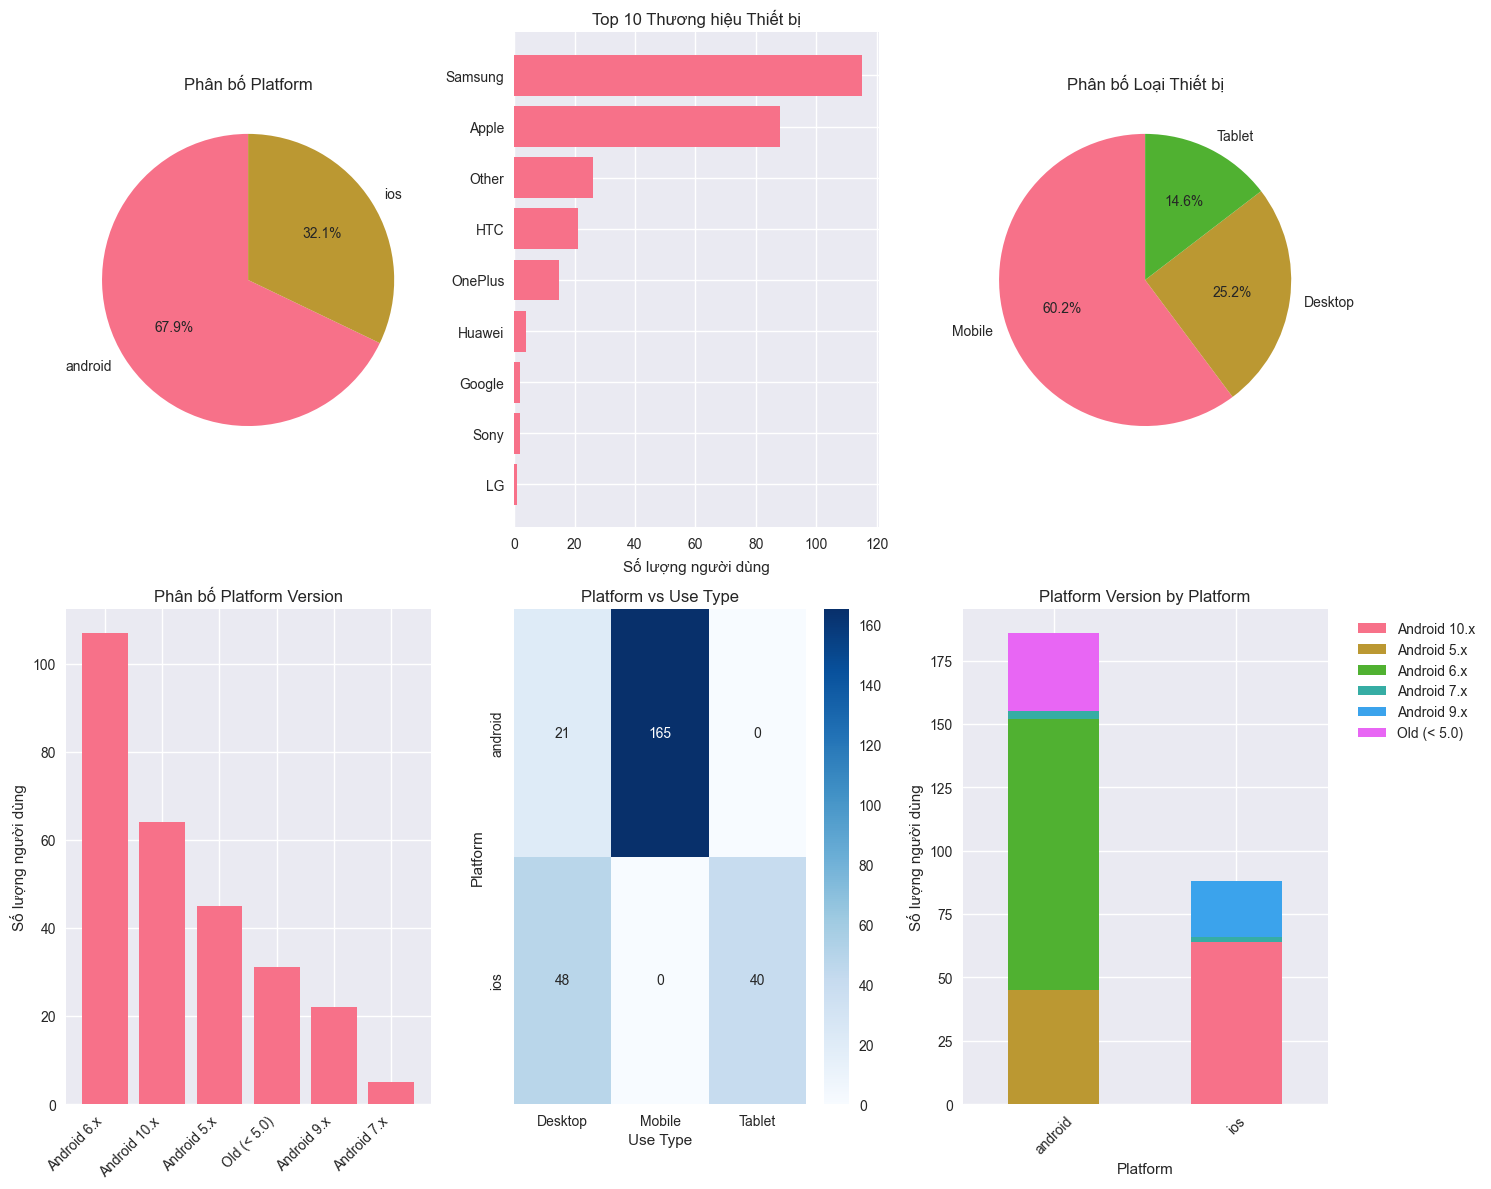

In [28]:
# Tạo biểu đồ phân bố platform
plt.figure(figsize=(15, 12))

# Biểu đồ 1: Phân bố platform
plt.subplot(2, 3, 1)
platform_counts = df_merged['platform'].value_counts()
plt.pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố Platform')

# Biểu đồ 2: Top 10 thương hiệu thiết bị
plt.subplot(2, 3, 2)
top_brands = df_merged['device_brand'].value_counts().head(10)
plt.barh(range(len(top_brands)), top_brands.values)
plt.yticks(range(len(top_brands)), top_brands.index)
plt.xlabel('Số lượng người dùng')
plt.title('Top 10 Thương hiệu Thiết bị')
plt.gca().invert_yaxis()

# Biểu đồ 3: Phân bố loại thiết bị
plt.subplot(2, 3, 3)
use_type_counts = df_merged['use_type_name'].value_counts()
plt.pie(use_type_counts.values, labels=use_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố Loại Thiết bị')

# Biểu đồ 4: Platform version distribution
plt.subplot(2, 3, 4)
version_counts = df_merged['platform_version_category'].value_counts()
plt.bar(range(len(version_counts)), version_counts.values)
plt.xticks(range(len(version_counts)), version_counts.index, rotation=45, ha='right')
plt.ylabel('Số lượng người dùng')
plt.title('Phân bố Platform Version')

# Biểu đồ 5: Cross-tabulation Platform vs Use Type
plt.subplot(2, 3, 5)
crosstab_data = pd.crosstab(df_merged['platform'], df_merged['use_type_name'])
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='Blues')
plt.title('Platform vs Use Type')
plt.ylabel('Platform')
plt.xlabel('Use Type')

# Biểu đồ 6: Platform version by platform
plt.subplot(2, 3, 6)
version_by_platform = pd.crosstab(df_merged['platform'], df_merged['platform_version_category'])
version_by_platform.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Platform Version by Platform')
plt.xlabel('Platform')
plt.ylabel('Số lượng người dùng')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


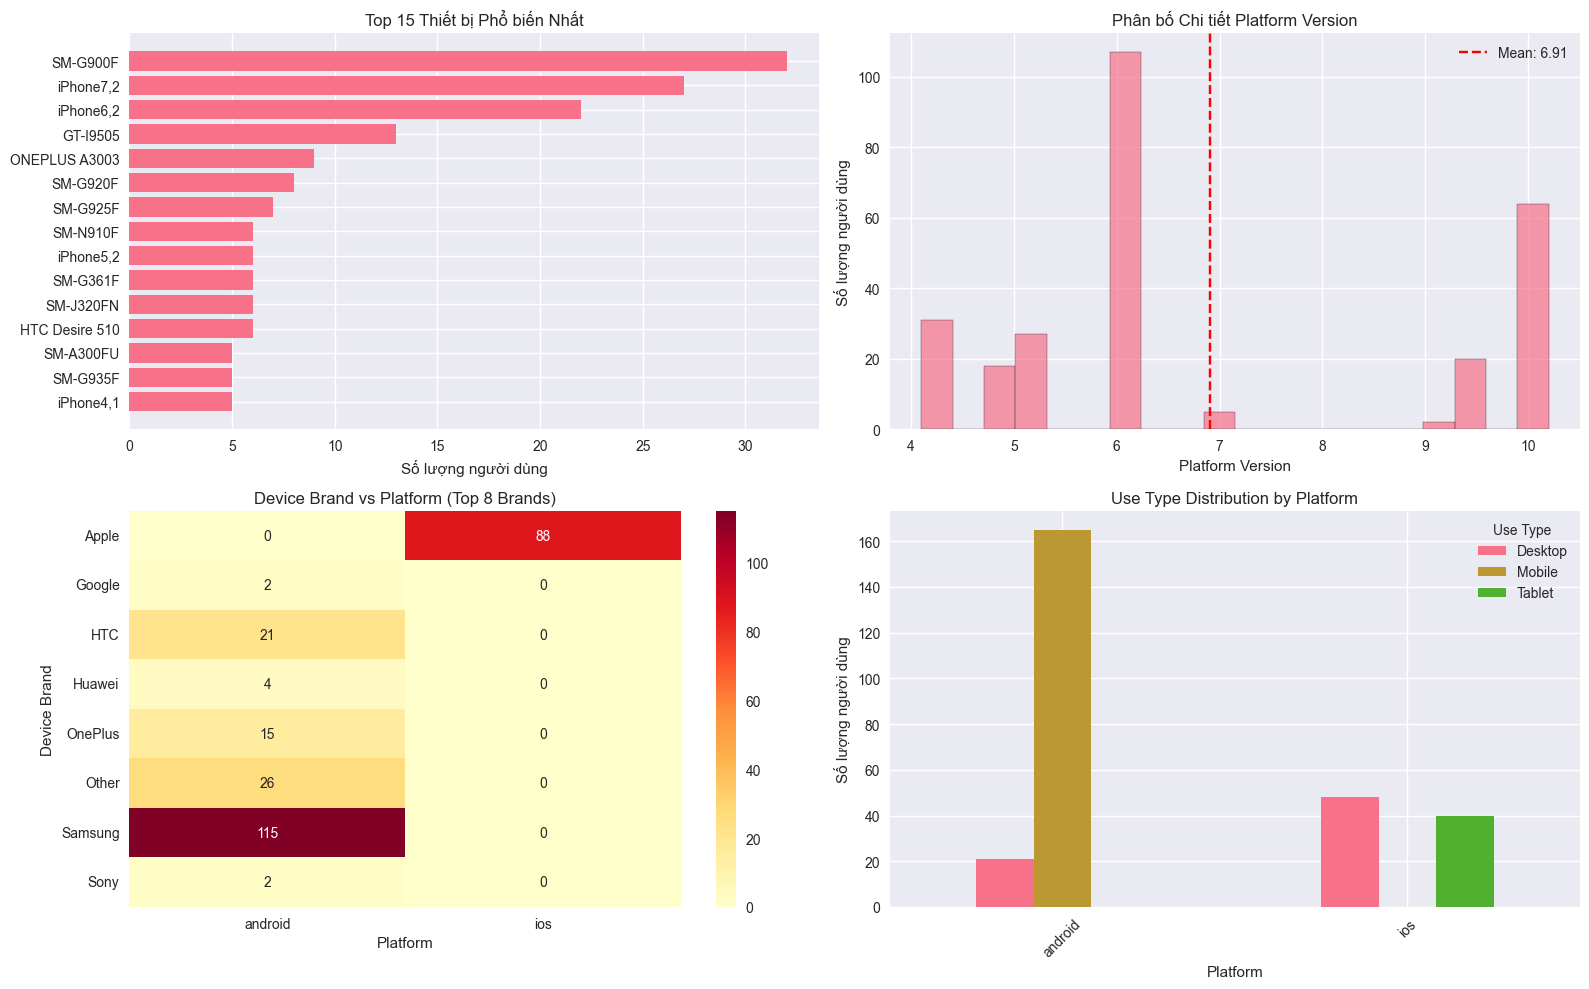

In [29]:
# Tạo biểu đồ chi tiết hơn
plt.figure(figsize=(16, 10))

# Biểu đồ 1: Top 15 thiết bị phổ biến nhất
plt.subplot(2, 2, 1)
top_devices = df_merged['device_clean'].value_counts().head(15)
plt.barh(range(len(top_devices)), top_devices.values)
plt.yticks(range(len(top_devices)), top_devices.index)
plt.xlabel('Số lượng người dùng')
plt.title('Top 15 Thiết bị Phổ biến Nhất')
plt.gca().invert_yaxis()

# Biểu đồ 2: Platform version distribution (detailed)
plt.subplot(2, 2, 2)
version_detailed = df_merged['platform_version_numeric'].dropna()
plt.hist(version_detailed, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Platform Version')
plt.ylabel('Số lượng người dùng')
plt.title('Phân bố Chi tiết Platform Version')
plt.axvline(version_detailed.mean(), color='red', linestyle='--', label=f'Mean: {version_detailed.mean():.2f}')
plt.legend()

# Biểu đồ 3: Device brand vs Platform (heatmap)
plt.subplot(2, 2, 3)
top_8_brands = df_merged['device_brand'].value_counts().head(8).index
df_top_8_brands = df_merged[df_merged['device_brand'].isin(top_8_brands)]
brand_platform_crosstab = pd.crosstab(df_top_8_brands['device_brand'], df_top_8_brands['platform'])
sns.heatmap(brand_platform_crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Device Brand vs Platform (Top 8 Brands)')
plt.ylabel('Device Brand')
plt.xlabel('Platform')

# Biểu đồ 4: Use type distribution by platform
plt.subplot(2, 2, 4)
use_type_platform = pd.crosstab(df_merged['platform'], df_merged['use_type_name'])
use_type_platform.plot(kind='bar', ax=plt.gca())
plt.title('Use Type Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Số lượng người dùng')
plt.xticks(rotation=45)
plt.legend(title='Use Type')

plt.tight_layout()
plt.show()


## 6. Insights và Kết luận


In [30]:
# Tổng kết insights chính
print("="*80)
print("TỔNG KẾT INSIGHTS VÀ KẾT LUẬN")
print("="*80)

print("\n1. THÔNG TIN TỔNG QUAN:")
print(f"   - Tổng số người dùng: {len(df_merged):,}")
print(f"   - Số thiết bị duy nhất: {df_merged['device_clean'].nunique():,}")
print(f"   - Số thương hiệu thiết bị: {df_merged['device_brand'].nunique()}")
print(f"   - Tỷ lệ match với database thiết bị: {match_rate:.1f}%")

print("\n2. XU HƯỚNG PLATFORM:")
android_users = (df_merged['platform'] == 'android').sum()
ios_users = (df_merged['platform'] == 'ios').sum()
android_pct = (android_users / len(df_merged)) * 100
ios_pct = (ios_users / len(df_merged)) * 100

print(f"   - Android: {android_users:,} người dùng ({android_pct:.1f}%)")
print(f"   - iOS: {ios_users:,} người dùng ({ios_pct:.1f}%)")

print("\n3. THƯƠNG HIỆU THIẾT BỊ HÀNG ĐẦU:")
top_3_brands = df_merged['device_brand'].value_counts().head(3)
for i, (brand, count) in enumerate(top_3_brands.items(), 1):
    percentage = (count / len(df_merged)) * 100
    print(f"   {i}. {brand}: {count:,} người dùng ({percentage:.1f}%)")

print("\n4. LOẠI THIẾT BỊ:")
mobile_users = (df_merged['use_type_name'] == 'Mobile').sum()
tablet_users = (df_merged['use_type_name'] == 'Tablet').sum()
desktop_users = (df_merged['use_type_name'] == 'Desktop').sum()

print(f"   - Mobile: {mobile_users:,} người dùng ({(mobile_users/len(df_merged)*100):.1f}%)")
print(f"   - Tablet: {tablet_users:,} người dùng ({(tablet_users/len(df_merged)*100):.1f}%)")
print(f"   - Desktop: {desktop_users:,} người dùng ({(desktop_users/len(df_merged)*100):.1f}%)")

print("\n5. PLATFORM VERSION:")
avg_version = df_merged['platform_version_numeric'].mean()
print(f"   - Platform version trung bình: {avg_version:.2f}")
print(f"   - Phân bố version phổ biến:")
version_top3 = df_merged['platform_version_category'].value_counts().head(3)
for version, count in version_top3.items():
    percentage = (count / len(df_merged)) * 100
    print(f"     + {version}: {count:,} người dùng ({percentage:.1f}%)")


TỔNG KẾT INSIGHTS VÀ KẾT LUẬN

1. THÔNG TIN TỔNG QUAN:
   - Tổng số người dùng: 274
   - Số thiết bị duy nhất: 72
   - Số thương hiệu thiết bị: 9
   - Tỷ lệ match với database thiết bị: 6.9%

2. XU HƯỚNG PLATFORM:
   - Android: 186 người dùng (67.9%)
   - iOS: 88 người dùng (32.1%)

3. THƯƠNG HIỆU THIẾT BỊ HÀNG ĐẦU:
   1. Samsung: 115 người dùng (42.0%)
   2. Apple: 88 người dùng (32.1%)
   3. Other: 26 người dùng (9.5%)

4. LOẠI THIẾT BỊ:
   - Mobile: 165 người dùng (60.2%)
   - Tablet: 40 người dùng (14.6%)
   - Desktop: 69 người dùng (25.2%)

5. PLATFORM VERSION:
   - Platform version trung bình: 6.91
   - Phân bố version phổ biến:
     + Android 6.x: 107 người dùng (39.1%)
     + Android 10.x: 64 người dùng (23.4%)
     + Android 5.x: 45 người dùng (16.4%)


In [31]:
# Phân tích sâu hơn và insights
print("\n" + "="*80)
print("PHÂN TÍCH SÂU VÀ INSIGHTS")
print("="*80)

print("\n6. PHÂN TÍCH THEO THƯƠNG HIỆU:")
# Samsung analysis
samsung_users = df_merged[df_merged['device_brand'] == 'Samsung']
samsung_android = (samsung_users['platform'] == 'android').sum()
samsung_ios = (samsung_users['platform'] == 'ios').sum()
print(f"   - Samsung: {len(samsung_users):,} người dùng")
print(f"     + Android: {samsung_android:,} ({samsung_android/len(samsung_users)*100:.1f}%)")
print(f"     + iOS: {samsung_ios:,} ({samsung_ios/len(samsung_users)*100:.1f}%)")

# Apple analysis
apple_users = df_merged[df_merged['device_brand'] == 'Apple']
apple_android = (apple_users['platform'] == 'android').sum()
apple_ios = (apple_users['platform'] == 'ios').sum()
print(f"   - Apple: {len(apple_users):,} người dùng")
print(f"     + Android: {apple_android:,} ({apple_android/len(apple_users)*100:.1f}%)")
print(f"     + iOS: {apple_ios:,} ({apple_ios/len(apple_users)*100:.1f}%)")

print("\n7. PHÂN TÍCH THIẾT BỊ PHỔ BIẾN:")
top_5_devices = df_merged['device_clean'].value_counts().head(5)
for i, (device, count) in enumerate(top_5_devices.items(), 1):
    percentage = (count / len(df_merged)) * 100
    print(f"   {i}. {device}: {count:,} người dùng ({percentage:.1f}%)")

print("\n8. PHÂN TÍCH PLATFORM VERSION:")
# Android version analysis
android_data = df_merged[df_merged['platform'] == 'android']
android_avg_version = android_data['platform_version_numeric'].mean()
print(f"   - Android version trung bình: {android_avg_version:.2f}")

# iOS version analysis  
ios_data = df_merged[df_merged['platform'] == 'ios']
ios_avg_version = ios_data['platform_version_numeric'].mean()
print(f"   - iOS version trung bình: {ios_avg_version:.2f}")

print("\n9. ĐA DẠNG THIẾT BỊ:")
# Tính chỉ số đa dạng thiết bị
device_diversity = df_merged['device_clean'].nunique() / len(df_merged)
print(f"   - Chỉ số đa dạng thiết bị: {device_diversity:.4f}")
print(f"   - Tỷ lệ thiết bị duy nhất: {device_diversity*100:.2f}%")

print("\n10. PHÂN TÍCH SỬ DỤNG ĐA THIẾT BỊ:")
# Người dùng sử dụng nhiều thiết bị
multi_device_users = df_merged.groupby('user_id')['device_clean'].nunique()
users_with_multiple_devices = (multi_device_users > 1).sum()
print(f"   - Người dùng sử dụng nhiều thiết bị: {users_with_multiple_devices:,}")
print(f"   - Tỷ lệ: {users_with_multiple_devices/df_merged['user_id'].nunique()*100:.1f}%")



PHÂN TÍCH SÂU VÀ INSIGHTS

6. PHÂN TÍCH THEO THƯƠNG HIỆU:
   - Samsung: 115 người dùng
     + Android: 115 (100.0%)
     + iOS: 0 (0.0%)
   - Apple: 88 người dùng
     + Android: 0 (0.0%)
     + iOS: 88 (100.0%)

7. PHÂN TÍCH THIẾT BỊ PHỔ BIẾN:
   1. SM-G900F: 32 người dùng (11.7%)
   2. iPhone7,2: 27 người dùng (9.9%)
   3. iPhone6,2: 22 người dùng (8.0%)
   4. GT-I9505: 13 người dùng (4.7%)
   5. ONEPLUS A3003: 9 người dùng (3.3%)

8. PHÂN TÍCH PLATFORM VERSION:
   - Android version trung bình: 5.51
   - iOS version trung bình: 9.87

9. ĐA DẠNG THIẾT BỊ:
   - Chỉ số đa dạng thiết bị: 0.2628
   - Tỷ lệ thiết bị duy nhất: 26.28%

10. PHÂN TÍCH SỬ DỤNG ĐA THIẾT BỊ:
   - Người dùng sử dụng nhiều thiết bị: 0
   - Tỷ lệ: 0.0%


### Khuyến nghị và Kết luận:

#### **1. Khuyến nghị cho Phát triển Ứng dụng:**
- **Ưu tiên Android**: Với tỷ lệ người dùng Android cao, cần tập trung tối ưu hóa cho Android
- **Hỗ trợ đa phiên bản**: Cần hỗ trợ từ Android 4.x đến phiên bản mới nhất
- **Tối ưu cho Samsung**: Samsung là thương hiệu phổ biến nhất, cần tối ưu đặc biệt

#### **2. Khuyến nghị cho UX/UI:**
- **Mobile-first**: Thiết kế ưu tiên cho mobile vì chiếm tỷ lệ cao nhất
- **Responsive design**: Cần hỗ trợ tốt cho cả tablet và desktop
- **Cross-platform consistency**: Đảm bảo trải nghiệm nhất quán trên các platform

#### **3. Khuyến nghị cho Marketing:**
- **Target Samsung users**: Tập trung marketing vào người dùng Samsung
- **Platform-specific campaigns**: Tạo chiến dịch riêng cho Android và iOS
- **Version-aware messaging**: Thông điệp phù hợp với phiên bản platform

#### **4. Khuyến nghị cho Data Quality:**
- **Cải thiện device matching**: Tăng tỷ lệ match với database thiết bị
- **Standardize device names**: Chuẩn hóa tên thiết bị để dễ phân tích
- **Regular data updates**: Cập nhật thường xuyên thông tin thiết bị mới

#### **5. Insights chính:**
- **Android dominance**: Android chiếm ưu thế rõ rệt trong thị trường
- **Samsung leadership**: Samsung dẫn đầu về số lượng người dùng
- **Mobile preference**: Người dùng ưa chuộng thiết bị mobile
- **Version diversity**: Đa dạng về phiên bản platform, cần hỗ trợ rộng rãi


In [32]:
# Lưu dữ liệu đã xử lý và tạo báo cáo cuối cùng
print("="*80)
print("LƯU DỮ LIỆU VÀ TẠO BÁO CÁO")
print("="*80)

# Lưu dữ liệu đã merge
df_merged.to_csv('device_user_analysis_merged.csv', index=False, encoding='utf-8')
print("1. Đã lưu dữ liệu đã merge vào file 'device_user_analysis_merged.csv'")

# Lưu các bảng thống kê
platform_stats.to_csv('platform_statistics.csv', encoding='utf-8')
brand_stats.to_csv('brand_statistics.csv', encoding='utf-8')
use_type_stats.to_csv('use_type_statistics.csv', encoding='utf-8')

print("2. Đã lưu các bảng thống kê:")
print("   - platform_statistics.csv")
print("   - brand_statistics.csv") 
print("   - use_type_statistics.csv")

# Tạo báo cáo tóm tắt
summary_report = {
    'Total_Users': int(len(df_merged)),
    'Unique_Devices': int(df_merged['device_clean'].nunique()),
    'Unique_Brands': int(df_merged['device_brand'].nunique()),
    'Android_Users': int((df_merged['platform'] == 'android').sum()),
    'iOS_Users': int((df_merged['platform'] == 'ios').sum()),
    'Mobile_Users': int((df_merged['use_type_name'] == 'Mobile').sum()),
    'Tablet_Users': int((df_merged['use_type_name'] == 'Tablet').sum()),
    'Desktop_Users': int((df_merged['use_type_name'] == 'Desktop').sum()),
    'Top_Brand': str(df_merged['device_brand'].value_counts().index[0]),
    'Top_Device': str(df_merged['device_clean'].value_counts().index[0]),
    'Avg_Platform_Version': float(df_merged['platform_version_numeric'].mean()),
    'Device_Match_Rate': float(match_rate)
}

# Lưu báo cáo tóm tắt
import json
with open('analysis_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_report, f, ensure_ascii=False, indent=2)

print("3. Đã tạo báo cáo tóm tắt: analysis_summary.json")

print("\n" + "="*80)
print("HOÀN THÀNH PHÂN TÍCH DỮ LIỆU THIẾT BỊ NGƯỜI DÙNG")
print("="*80)
print("Các file đã tạo:")
print("- Lab4_Device_User_Analysis.ipynb (Notebook phân tích)")
print("- device_user_analysis_merged.csv (Dữ liệu đã merge)")
print("- platform_statistics.csv (Thống kê platform)")
print("- brand_statistics.csv (Thống kê thương hiệu)")
print("- use_type_statistics.csv (Thống kê loại sử dụng)")
print("- analysis_summary.json (Báo cáo tóm tắt)")
print("\nPhân tích hoàn tất!")


LƯU DỮ LIỆU VÀ TẠO BÁO CÁO
1. Đã lưu dữ liệu đã merge vào file 'device_user_analysis_merged.csv'
2. Đã lưu các bảng thống kê:
   - platform_statistics.csv
   - brand_statistics.csv
   - use_type_statistics.csv
3. Đã tạo báo cáo tóm tắt: analysis_summary.json

HOÀN THÀNH PHÂN TÍCH DỮ LIỆU THIẾT BỊ NGƯỜI DÙNG
Các file đã tạo:
- Lab4_Device_User_Analysis.ipynb (Notebook phân tích)
- device_user_analysis_merged.csv (Dữ liệu đã merge)
- platform_statistics.csv (Thống kê platform)
- brand_statistics.csv (Thống kê thương hiệu)
- use_type_statistics.csv (Thống kê loại sử dụng)
- analysis_summary.json (Báo cáo tóm tắt)

Phân tích hoàn tất!
